In [1]:
# ============================================================
# Cell 1 - Import Libraries
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report

)

import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Cell 2 - Load Dataset
# ============================================================

df = pd.read_csv("../results/reliability_dataset_v2.csv")

print("=" * 60)
print("UAIRE DATASET")
print("=" * 60)

print()

print("Shape :", df.shape)

print()

print(df.head())

UAIRE DATASET

Shape : (10000, 35)

   confidence   entropy  prediction_margin  activation_mean  activation_std  \
0    0.693736  1.112976           0.558915         0.370606        0.489552   
1    0.684337  0.868562           0.466290         1.074382        1.307902   
2    0.825382  0.580671           0.679395         0.695826        0.833168   
3    0.971878  0.170356           0.960077         0.510351        0.751364   
4    0.759581  0.774034           0.632923         0.608280        0.922197   

   activation_max  activation_min  activation_energy  activation_sparsity  \
0        3.145806             0.0           0.376542             0.298828   
1        6.743713             0.0           2.861562             0.423828   
2        4.562689             0.0           1.176987             0.410156   
3        3.695982             0.0           0.823904             0.347656   
4        4.602489             0.0           1.218791             0.277344   

   dead_neuron_ratio  ... 

In [3]:
# ============================================================
# Cell 3 - Dataset Analysis
# ============================================================

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(df.isnull().sum())

print()

print("=" * 60)
print("Failure Distribution")
print("=" * 60)

print(df["failure_label"].value_counts())

print()

print(df["failure_label"].value_counts(normalize=True))

Missing Values
confidence                   0
entropy                      0
prediction_margin            0
activation_mean              0
activation_std               0
activation_max               0
activation_min               0
activation_energy            0
activation_sparsity          0
dead_neuron_ratio            0
positive_activation_ratio    0
activation_entropy           0
gradient_mean                0
gradient_std                 0
gradient_max                 0
gradient_min                 0
gradient_norm                0
gradient_energy              0
gradient_sparsity            0
gradient_entropy             0
brightness                   0
contrast                     0
image_entropy                0
blur_score                   0
laplacian_variance           0
edge_density                 0
msp_probability              0
msp_ood_score                0
energy_score                 0
normalized_energy            0
mahalanobis_distance         0
mahalanobis_available   

In [4]:
# ============================================================
# Cell 4 - Prepare Features
# ============================================================

X = df.drop(

    columns=[

        "prediction",

        "true_label",

        "failure_label"

    ]

)

y = df["failure_label"]

print("Features :", X.shape[1])

print("Samples :", X.shape[0])

Features : 32
Samples : 10000


In [5]:
# ============================================================
# Cell 5 - Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 8000
Testing Samples : 2000


In [6]:
# ============================================================
# Cell 6 - Train Random Forest
# ============================================================

rf = RandomForestClassifier(

    n_estimators=300,

    max_depth=None,

    random_state=42,

    n_jobs=-1,

    class_weight="balanced"

)

rf.fit(X_train, y_train)

print("Random Forest Trained Successfully!")

Random Forest Trained Successfully!


In [7]:
# ============================================================
# Cell 7 - Evaluate Random Forest
# ============================================================

y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 60)
print("UAIRE RANDOM FOREST V2")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print()

print(classification_report(y_test, y_pred))

UAIRE RANDOM FOREST V2
Accuracy : 0.7515
Precision: 0.5548
Recall   : 0.6794
F1 Score : 0.6108
ROC-AUC  : 0.8206

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1426
           1       0.55      0.68      0.61       574

    accuracy                           0.75      2000
   macro avg       0.71      0.73      0.71      2000
weighted avg       0.77      0.75      0.76      2000



In [8]:
# ============================================================
# Cell 8 - Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.reset_index(

    drop=True,

    inplace=True

)

importance.head(20)

,Feature,Importance
0,prediction_margin,0.087064
1,confidence,0.080646
2,msp_probability,0.073734
3,entropy,0.071924
4,msp_ood_score,0.071121
5,energy_score,0.056737
6,normalized_energy,0.046940
7,activation_entropy,0.045905
8,activation_max,0.039627
9,activation_mean,0.036712


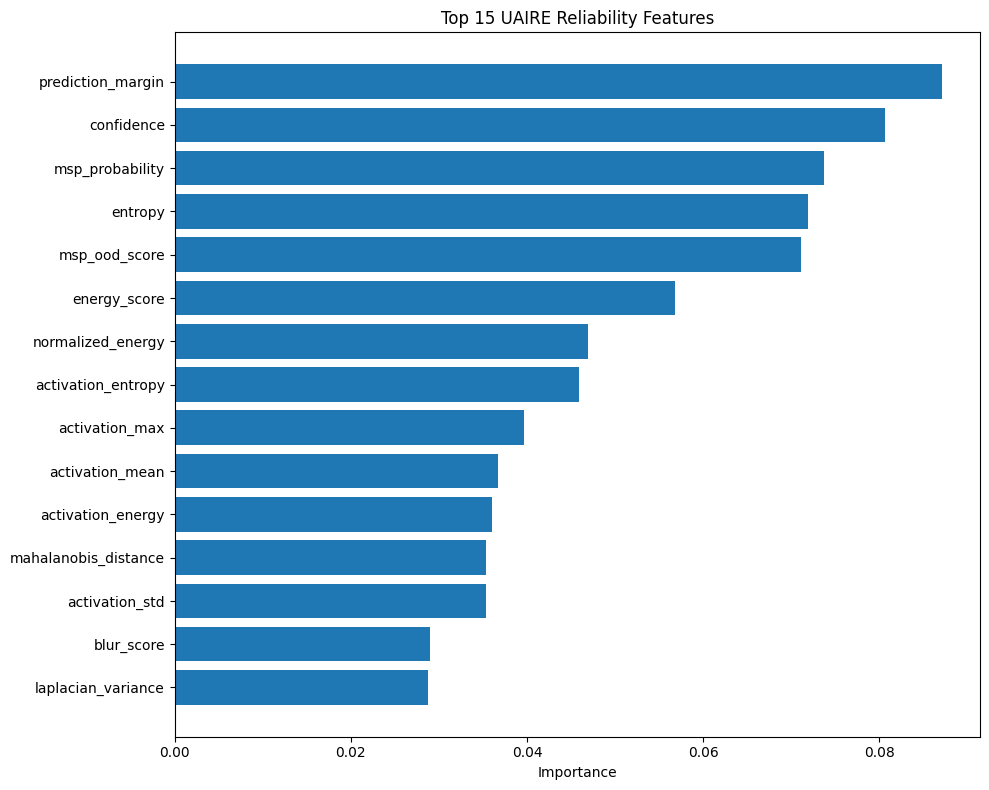

In [9]:
# ============================================================
# Cell 9 - Plot Feature Importance
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(

    importance["Feature"][:15][::-1],

    importance["Importance"][:15][::-1]

)

plt.xlabel("Importance")

plt.title("Top 15 UAIRE Reliability Features")

plt.tight_layout()

plt.show()

In [10]:
# ============================================================
# Cell 10 - Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1113  313]
 [ 184  390]]


In [11]:
# ============================================================
# Cell 11 - Save Model
# ============================================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(

    rf,

    "../models/uaire_random_forest_v2.pkl"

)

print("Model Saved Successfully!")

Model Saved Successfully!


In [12]:
# ============================================================
# Cell 12 - Feature Ablation (Remove Duplicate MSP Features)
# ============================================================

drop_features = [

    "msp_probability",
    "msp_ood_score"

]

X_reduced = X.drop(columns=drop_features)

print("Original Features :", X.shape[1])
print("Reduced Features  :", X_reduced.shape[1])

Original Features : 32
Reduced Features  : 30


In [13]:
# ============================================================
# Cell 13 - Train/Test Split
# ============================================================

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X_reduced,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [14]:
# ============================================================
# Cell 14 - Train Random Forest
# ============================================================

rf_reduced = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    class_weight="balanced",

    n_jobs=-1

)

rf_reduced.fit(

    X_train_r,

    y_train_r

)

print("Reduced Model Trained")

Reduced Model Trained


In [15]:
# ============================================================
# Cell 15 - Evaluation
# ============================================================

y_pred = rf_reduced.predict(X_test_r)

y_prob = rf_reduced.predict_proba(X_test_r)[:,1]

accuracy = accuracy_score(y_test_r,y_pred)

precision = precision_score(y_test_r,y_pred)

recall = recall_score(y_test_r,y_pred)

f1 = f1_score(y_test_r,y_pred)

roc = roc_auc_score(y_test_r,y_prob)

print("="*60)

print("UAIRE Feature Ablation")

print("="*60)

print()

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")

UAIRE Feature Ablation

Accuracy : 0.7525
Precision: 0.5565
Recall   : 0.6777
F1       : 0.6112
ROC-AUC  : 0.8255


In [16]:
# ============================================================
# Cell 16 - Top 15 Features
# ============================================================

top15 = importance.head(15)["Feature"].tolist()

print(top15)

['prediction_margin', 'confidence', 'msp_probability', 'entropy', 'msp_ood_score', 'energy_score', 'normalized_energy', 'activation_entropy', 'activation_max', 'activation_mean', 'activation_energy', 'mahalanobis_distance', 'activation_std', 'blur_score', 'laplacian_variance']


In [17]:
# ============================================================
# Cell 17 - Build Dataset
# ============================================================

X_top = X[top15]

print(X_top.shape)

(10000, 15)


In [18]:
# ============================================================
# Cell 18 - Split
# ============================================================

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(

    X_top,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [19]:
# ============================================================
# Cell 19 - Train
# ============================================================

rf_top = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    class_weight="balanced",

    n_jobs=-1

)

rf_top.fit(

    X_train_t,

    y_train_t

)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [20]:
# ============================================================
# Cell 20 - Evaluate
# ============================================================

y_pred = rf_top.predict(X_test_t)

y_prob = rf_top.predict_proba(X_test_t)[:,1]

results = {

    "Accuracy": accuracy_score(y_test_t,y_pred),

    "Precision": precision_score(y_test_t,y_pred),

    "Recall": recall_score(y_test_t,y_pred),

    "F1": f1_score(y_test_t,y_pred),

    "ROC_AUC": roc_auc_score(y_test_t,y_prob)

}

pd.DataFrame([results])

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.732,0.525469,0.682927,0.593939,0.794706


In [21]:
comparison = pd.DataFrame({

    "Model":[
        "UAIRE RF (32 Features)",
        "UAIRE RF (30 Features)",
        "UAIRE RF (Top15)"
    ],

    "Accuracy":[...],

    "Precision":[...],

    "Recall":[...],

    "F1":[...],

    "ROC_AUC":[...]

})

comparison

ValueError: All arrays must be of the same length